In [1]:
from models import *

path = "../data/Fashion-MNIST"
X_train, y_train, X_test, y_test = load_MINST_dataset(path)
X_train, X_test = flatten_images(X_train, X_test)

In [2]:
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

def tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, dim_reduction):
    results = {}
    
    for c in c_options:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('reduce_dim', dim_reduction),
            ('svc', SVC(kernel='linear', C=c, random_state=42))
        ], verbose=True)
        print(f"Training Linear SVC with C={c}...")
        results[c] = evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test)
        
    return results

def plot_pipeline_results(result, title):
    x = list(result.keys())
    train_time = [result[k]['train_time'] for k in x]
    train_acc = [result[k]['train_acc'] for k in x]
    test_acc = [result[k]['test_acc'] for k in x]

    plt.figure(figsize=(6.5, 4.5))

    # Accuracy
    plt.plot(x, train_acc, marker='o', label='Train Accuracy', color='blue')
    plt.plot(x, test_acc, marker='s', label='Test Accuracy', color='green')
    plt.xscale('log')
    plt.xlabel('Hyperparameter (C)')
    plt.ylabel('Accuracy')
    plt.title(f'Training and Test Accuracy ({title})')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(result).T
    table = table[['train_time', 'train_acc', 'test_acc']].copy()
    table.columns = ['Training Time','Training Accuracy', 'Test Accuracy']

    return result, table

In [ ]:
# c_options = [0.0001, 0.001, 0.01, 0.1, 1, 10]
# results = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options, )
# results, table = plot_pipeline_results(results, "Without Reduction")
# print(results)
# print(table)

Training Linear SVC with C=0.0001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.3s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.1s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.9min
Training Linear SVC with C=0.001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.3min
Training Linear SVC with C=0.01...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.7s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.2min
Training Linear SVC with C=0.1...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.1s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.7s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.7min
Traini

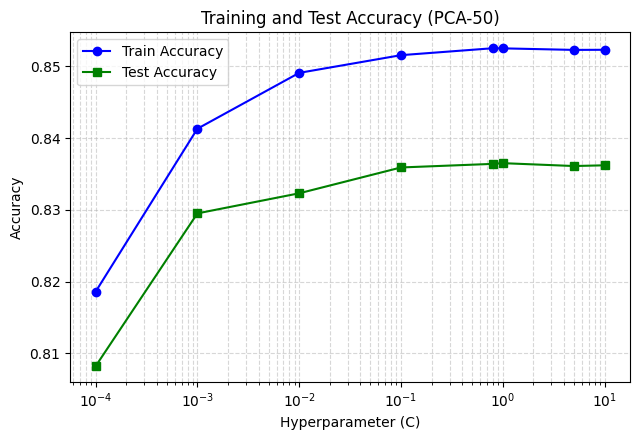

{0.0001: {'train_time': 117.5249358000001, 'train_acc': 0.8185833333333333, 'test_acc': 0.8082}, 0.001: {'train_time': 79.523151100002, 'train_acc': 0.8413, 'test_acc': 0.8295}, 0.01: {'train_time': 73.3518383000046, 'train_acc': 0.8490833333333333, 'test_acc': 0.8323}, 0.1: {'train_time': 102.6882973999891, 'train_acc': 0.85155, 'test_acc': 0.8359}, 0.8: {'train_time': 237.0344395999855, 'train_acc': 0.8525166666666667, 'test_acc': 0.8364}, 1: {'train_time': 269.4587710000051, 'train_acc': 0.8525, 'test_acc': 0.8365}, 5: {'train_time': 818.6399580000143, 'train_acc': 0.8522833333333333, 'test_acc': 0.8361}, 10: {'train_time': 1465.6245293000247, 'train_acc': 0.8523, 'test_acc': 0.8362}}
         Training Time  Training Accuracy  Test Accuracy
0.0001      117.524936           0.818583         0.8082
0.0010       79.523151           0.841300         0.8295
0.0100       73.351838           0.849083         0.8323
0.1000      102.688297           0.851550         0.8359
0.8000      237.03

In [ ]:
c_options_50 = [0.0001, 0.001, 0.01, 0.1, 0.8, 1, 5, 10]
results_50 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options_50, PCA(n_components=50))
results_50, table_50 = plot_pipeline_results(results_50, "PCA-50")
print(results_50)
print(table_50)

Training Linear SVC with C=0.0001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.9s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.4min
Training Linear SVC with C=0.001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.6min
Training Linear SVC with C=0.01...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.5min
Training Linear SVC with C=0.05...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.1s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.8min
Train

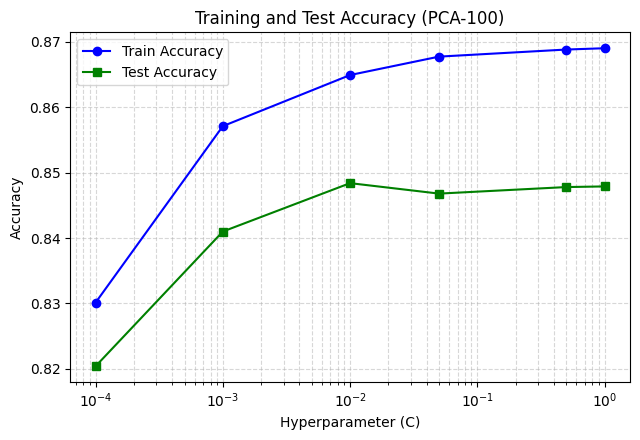

{0.0001: {'train_time': 145.94821479999882, 'train_acc': 0.8301333333333333, 'test_acc': 0.8204}, 0.001: {'train_time': 96.16756309999982, 'train_acc': 0.8571166666666666, 'test_acc': 0.841}, 0.01: {'train_time': 89.3726329000001, 'train_acc': 0.8649333333333333, 'test_acc': 0.8484}, 0.05: {'train_time': 111.88248629999907, 'train_acc': 0.86775, 'test_acc': 0.8468}, 0.5: {'train_time': 238.80999820000034, 'train_acc': 0.8688333333333333, 'test_acc': 0.8478}, 1: {'train_time': 361.5323456999995, 'train_acc': 0.8690333333333333, 'test_acc': 0.8479}}
        Training Time  Training Accuracy  Test Accuracy
0.0001     145.948215           0.830133         0.8204
0.0010      96.167563           0.857117         0.8410
0.0100      89.372633           0.864933         0.8484
0.0500     111.882486           0.867750         0.8468
0.5000     238.809998           0.868833         0.8478
1.0000     361.532346           0.869033         0.8479


In [ ]:
c_options_100 = [0.0001, 0.001, 0.01, 0.05, 0.5, 1]
results_100 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options_100, PCA(n_components=100))
results_100, table_100 = plot_pipeline_results(results_100, "PCA-100")
print(results_100)
print(table_100)

Training Linear SVC with C=0.0001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.4s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 3.2min
Training Linear SVC with C=0.001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   0.9s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.2min
Training Linear SVC with C=0.01...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   1.3s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 1.9min
Training Linear SVC with C=0.1...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.1s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=   2.2s
[Pipeline] ............... (step 3 of 3) Processing svc, total= 2.6min
Traini

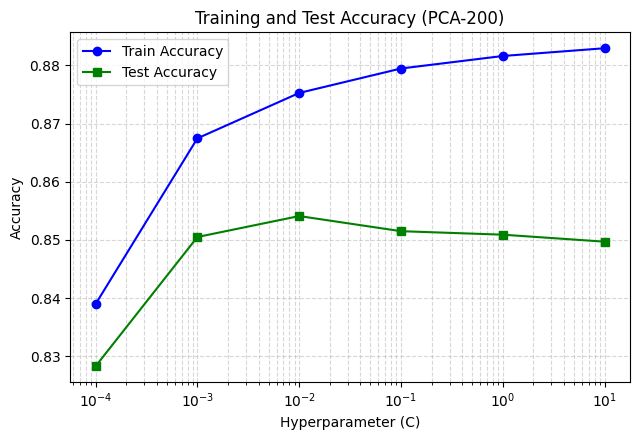

{0.0001: {'train_time': 194.27361979999114, 'train_acc': 0.8389833333333333, 'test_acc': 0.8283}, 0.001: {'train_time': 131.9020933000138, 'train_acc': 0.86745, 'test_acc': 0.8505}, 0.01: {'train_time': 118.5065084999951, 'train_acc': 0.87525, 'test_acc': 0.8541}, 0.1: {'train_time': 158.5252870999975, 'train_acc': 0.87945, 'test_acc': 0.8515}, 1: {'train_time': 478.74788529999205, 'train_acc': 0.8816, 'test_acc': 0.8509}, 10: {'train_time': 3311.261016399978, 'train_acc': 0.8829333333333333, 'test_acc': 0.8497}}
         Training Time  Training Accuracy  Test Accuracy
0.0001      194.273620           0.838983         0.8283
0.0010      131.902093           0.867450         0.8505
0.0100      118.506508           0.875250         0.8541
0.1000      158.525287           0.879450         0.8515
1.0000      478.747885           0.881600         0.8509
10.0000    3311.261016           0.882933         0.8497


In [ ]:
c_options_200 = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results_200 = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options_200, PCA(n_components=200))
results_200, table_200 = plot_pipeline_results(results_200, "PCA-200")
print(results_200)
print(table_200)

Training Linear SVC with C=0.0001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   2.5s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  15.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  58.5s
Training Linear SVC with C=0.001...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.0s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.8s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  28.7s
Training Linear SVC with C=0.01...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.2s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.6s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  20.7s
Training Linear SVC with C=0.1...
[Pipeline] ............ (step 1 of 3) Processing scaler, total=   1.0s
[Pipeline] ........ (step 2 of 3) Processing reduce_dim, total=  12.0s
[Pipeline] ............... (step 3 of 3) Processing svc, total=  21.3s
Traini

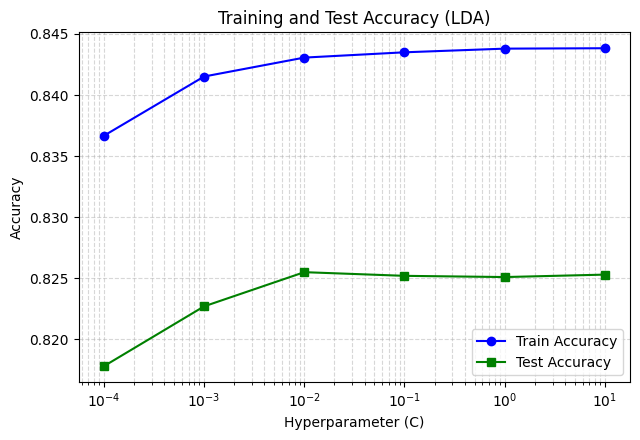

{0.0001: {'train_time': 76.17661260001478, 'train_acc': 0.8366666666666667, 'test_acc': 0.8178}, 0.001: {'train_time': 42.45707560001756, 'train_acc': 0.8415166666666667, 'test_acc': 0.8227}, 0.01: {'train_time': 34.46086560000549, 'train_acc': 0.8430666666666666, 'test_acc': 0.8255}, 0.1: {'train_time': 34.35114449998946, 'train_acc': 0.8435, 'test_acc': 0.8252}, 1: {'train_time': 49.125244299997576, 'train_acc': 0.8438, 'test_acc': 0.8251}, 10: {'train_time': 103.87503910000669, 'train_acc': 0.8438333333333333, 'test_acc': 0.8253}}
         Training Time  Training Accuracy  Test Accuracy
0.0001       76.176613           0.836667         0.8178
0.0010       42.457076           0.841517         0.8227
0.0100       34.460866           0.843067         0.8255
0.1000       34.351144           0.843500         0.8252
1.0000       49.125244           0.843800         0.8251
10.0000     103.875039           0.843833         0.8253


In [ ]:
c_options_lda = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results_lda = tune_linear_pipeline(X_train, y_train, X_test, y_test, c_options_lda, LinearDiscriminantAnalysis(n_components=9))
results_lda, table_lda = plot_pipeline_results(results_lda, "LDA")
print(results_lda)
print(table_lda)